In [2]:
import numpy as np
import pandas as pd
import os

df = pd.read_csv('D:/mamba_model/thesis_cohort_final.csv')
mri_cache = 'D:/mamba_model/preprocessed_cache_v3'
pet_cache = 'D:/mamba_model/preprocessed_cache_pet'

mri_ok = 0
pet_ok = 0
mismatch = []

for _, row in df.iterrows():
    subject_id  = row['subject_id']
    mri_session = row['mri_session']

    mri_path = f'{mri_cache}/{mri_session}.npy'
    pet_path = f'{pet_cache}/{subject_id}_PIB.npy'

    mri_exists = os.path.exists(mri_path)
    pet_exists = os.path.exists(pet_path)

    if mri_exists: mri_ok += 1
    if pet_exists: pet_ok += 1

    if mri_exists and pet_exists:
        mri_arr = np.load(mri_path)
        pet_arr = np.load(pet_path)
        if mri_arr.shape != pet_arr.shape:
            mismatch.append(f'{subject_id}: MRI={mri_arr.shape} PET={pet_arr.shape}')

print(f'MRI cache: {mri_ok}/210')
print(f'PET cache: {pet_ok}/210')
print(f'Shape mismatches: {len(mismatch)}')

# Sample subject
test_subj = df.iloc[0]
mri = np.load(f"{mri_cache}/{test_subj['mri_session']}.npy")
pet = np.load(f"{pet_cache}/{test_subj['subject_id']}_PIB.npy")
print(f'\nSample: {test_subj["subject_id"]}')
print(f'MRI shape: {mri.shape}')
print(f'PET shape: {pet.shape}')
print('Ready!')

MRI cache: 210/210
PET cache: 210/210
Shape mismatches: 210

Sample: OAS30564
MRI shape: (100, 100, 100)
PET shape: (6, 64, 64, 64)
Ready!


In [3]:
import numpy as np
test = np.load('D:/mamba_model/preprocessed_cache_v3/OAS30001_MR_d0757.npy')
print(test.shape)

(100, 100, 100)


In [4]:
import os
for f in os.listdir('D:/mamba_model'):
    if 'cache' in f.lower() or 'roi' in f.lower():
        print(f)

cache
cache_fullbrain
extract_pet_rois.py
preprocessed_cache
preprocessed_cache_fullbrain_aug
preprocessed_cache_pet
preprocessed_cache_roi
preprocessed_cache_roi32
preprocessed_cache_roi64
preprocessed_cache_roi64_aug
preprocessed_cache_v2
preprocessed_cache_v3
roi_visualisation.png


In [5]:
import numpy as np
import os

folders = ['preprocessed_cache_roi64', 'preprocessed_cache_roi64_aug', 'preprocessed_cache_roi']

for folder in folders:
    path = f'D:/mamba_model/{folder}'
    files = os.listdir(path)
    print(f'{folder}: {len(files)} files')
    if files:
        sample = np.load(f'{path}/{files[0]}')
        print(f'  sample shape: {sample.shape}')
        print(f'  sample name: {files[0]}')

preprocessed_cache_roi64: 210 files
  sample shape: (6, 64, 64, 64)
  sample name: OAS30001_MR_d0757.npy
preprocessed_cache_roi64_aug: 588 files
  sample shape: (6, 64, 64, 64)
  sample name: OAS30001_MR_d0757_aug1.npy
preprocessed_cache_roi: 210 files
  sample shape: (6, 32, 32, 32)
  sample name: OAS30001_MR_d0757.npy


In [6]:
mri_cache = 'D:/mamba_model/preprocessed_cache_roi64'
pet_cache = 'D:/mamba_model/preprocessed_cache_pet'

mri_ok = 0
pet_ok = 0
mismatch = []

for _, row in df.iterrows():
    subject_id  = row['subject_id']
    mri_session = row['mri_session']

    mri_path = f'{mri_cache}/{mri_session}.npy'
    pet_path = f'{pet_cache}/{subject_id}_PIB.npy'

    mri_exists = os.path.exists(mri_path)
    pet_exists = os.path.exists(pet_path)

    if mri_exists: mri_ok += 1
    if pet_exists: pet_ok += 1

    if mri_exists and pet_exists:
        mri_arr = np.load(mri_path)
        pet_arr = np.load(pet_path)
        if mri_arr.shape != pet_arr.shape:
            mismatch.append(f'{subject_id}: MRI={mri_arr.shape} PET={pet_arr.shape}')

print(f'MRI cache: {mri_ok}/210')
print(f'PET cache: {pet_ok}/210')
print(f'Shape mismatches: {len(mismatch)}')

test_subj = df.iloc[0]
mri = np.load(f"{mri_cache}/{test_subj['mri_session']}.npy")
pet = np.load(f"{pet_cache}/{test_subj['subject_id']}_PIB.npy")
print(f'\nSample: {test_subj["subject_id"]}')
print(f'MRI shape: {mri.shape}')
print(f'PET shape: {pet.shape}')
print('Ready!')

MRI cache: 210/210
PET cache: 210/210
Shape mismatches: 0

Sample: OAS30564
MRI shape: (6, 64, 64, 64)
PET shape: (6, 64, 64, 64)
Ready!


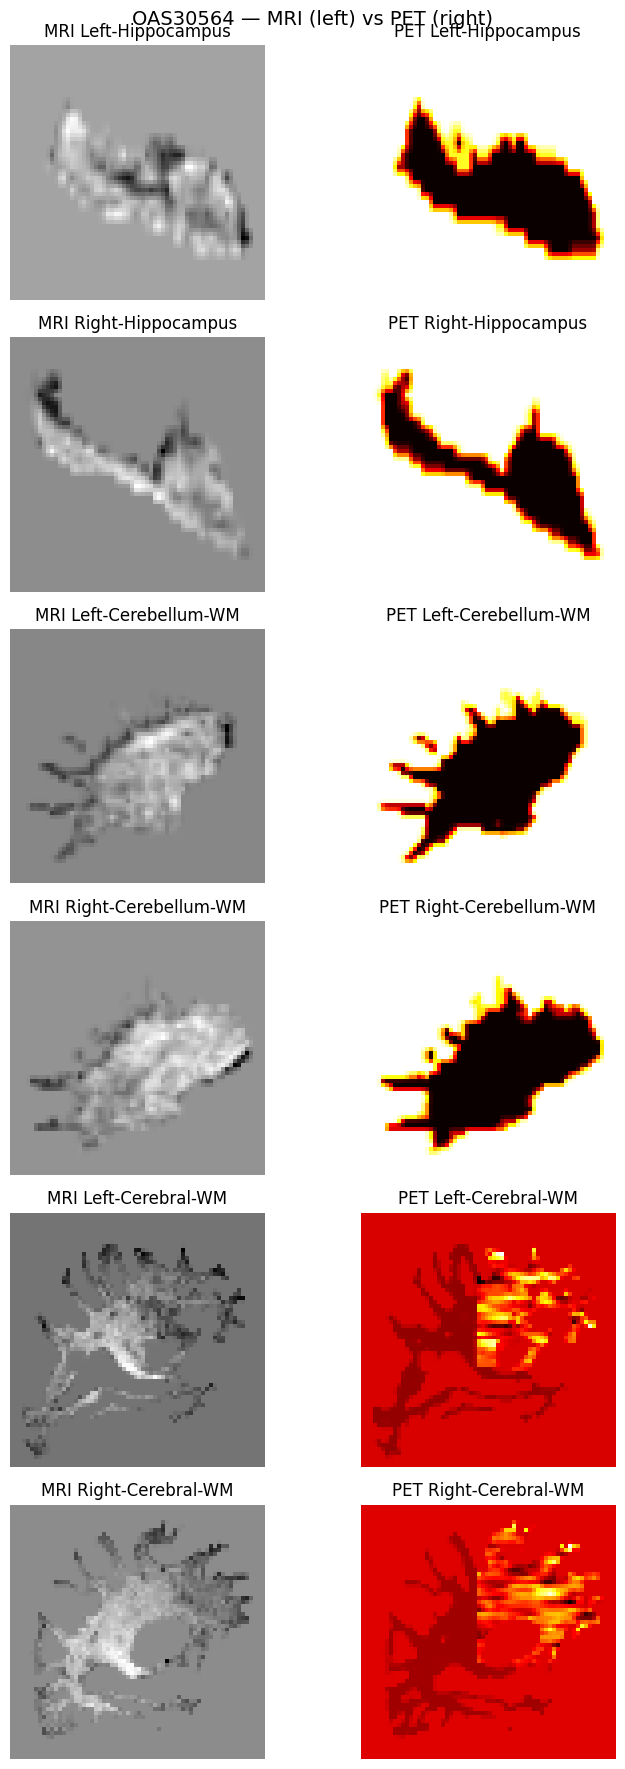

Saved to D:/mamba_model/mri_pet_roi_comparison.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np

ROI_NAMES = [
    'Left-Hippocampus', 'Right-Hippocampus',
    'Left-Cerebellum-WM', 'Right-Cerebellum-WM',
    'Left-Cerebral-WM', 'Right-Cerebral-WM'
]

# Load one subject
test_subj = df.iloc[0]
mri = np.load(f"{mri_cache}/{test_subj['mri_session']}.npy")
pet = np.load(f"{pet_cache}/{test_subj['subject_id']}_PIB.npy")

fig, axes = plt.subplots(6, 2, figsize=(8, 18))
fig.suptitle(f"{test_subj['subject_id']} — MRI (left) vs PET (right)", fontsize=14)

for i, roi_name in enumerate(ROI_NAMES):
    # Take middle slice
    mid = 32
    mri_slice = mri[i, mid, :, :]
    pet_slice = pet[i, mid, :, :]

    axes[i, 0].imshow(mri_slice, cmap='gray')
    axes[i, 0].set_title(f'MRI {roi_name}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(pet_slice, cmap='hot')
    axes[i, 1].set_title(f'PET {roi_name}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig('D:/mamba_model/mri_pet_roi_comparison.png', dpi=150)
plt.show()
print('Saved to D:/mamba_model/mri_pet_roi_comparison.png')

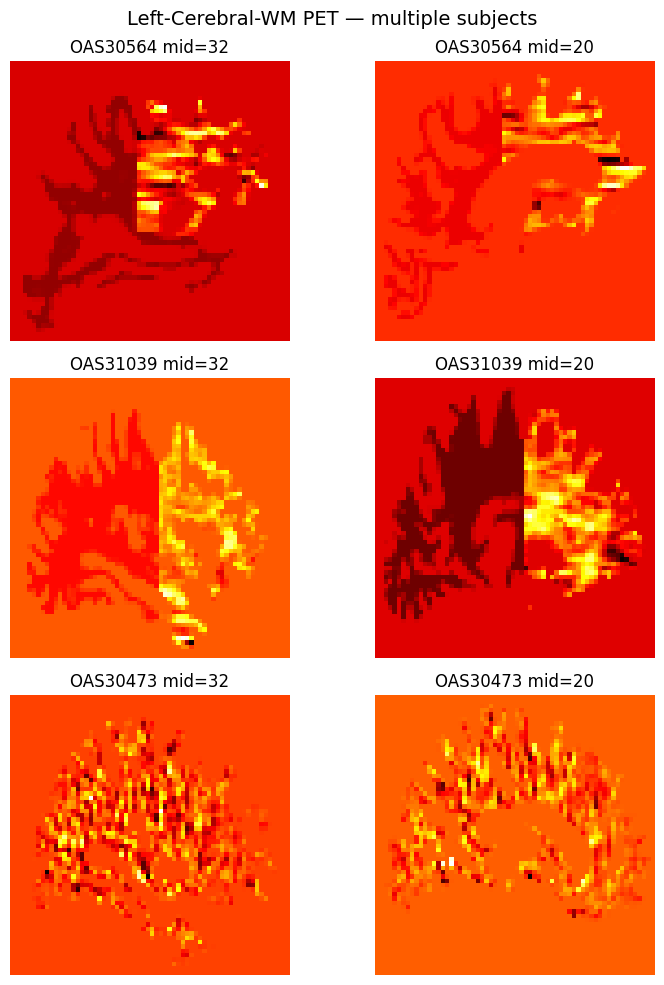

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
fig.suptitle('Left-Cerebral-WM PET — multiple subjects', fontsize=14)

for i in range(3):
    subj = df.iloc[i]
    pet = np.load(f"{pet_cache}/{subj['subject_id']}_PIB.npy")
    mid = 32
    pet_slice = pet[4, mid, :, :]  # index 4 = Left-Cerebral-WM
    
    axes[i, 0].imshow(pet_slice, cmap='hot')
    axes[i, 0].set_title(f"{subj['subject_id']} mid={mid}")
    axes[i, 0].axis('off')
    
    # Try different slice
    pet_slice2 = pet[4, 20, :, :]
    axes[i, 1].imshow(pet_slice2, cmap='hot')
    axes[i, 1].set_title(f"{subj['subject_id']} mid=20")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

PET shape: (256, 256, 256)
MRI shape: (256, 256, 256)


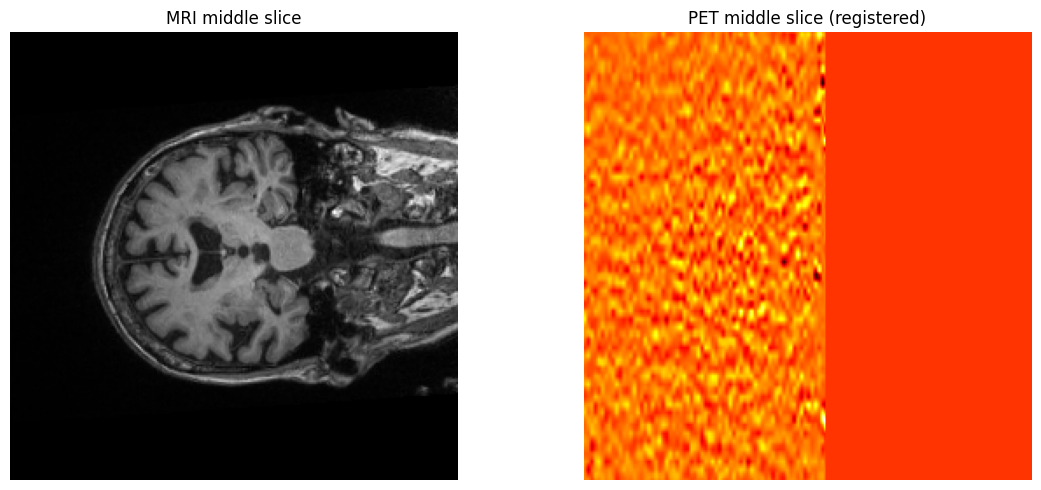

In [9]:
import nibabel as nib
import matplotlib.pyplot as plt

# Load raw registered PET (before any masking)
subj = df.iloc[0]  # OAS30564
pet_raw = nib.load(f"E:/Oasis3/PET_registered/{subj['subject_id']}_PIB_in_MRI.nii.gz").get_fdata()
mri_raw = nib.load(f"E:/Oasis3/FastSurfer_output/{subj['mri_session']}/mri/orig.nii.gz").get_fdata()

print(f'PET shape: {pet_raw.shape}')
print(f'MRI shape: {mri_raw.shape}')

# Show middle slice of both
mid = pet_raw.shape[2] // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(mri_raw[:, :, mid], cmap='gray', origin='lower')
axes[0].set_title('MRI middle slice')
axes[0].axis('off')

axes[1].imshow(pet_raw[:, :, mid, 0] if pet_raw.ndim == 4 else pet_raw[:, :, mid], 
               cmap='hot', origin='lower')
axes[1].set_title('PET middle slice (registered)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [10]:
pet = np.load(f"{pet_cache}/{test_subj['subject_id']}_PIB.npy")

In [13]:
import os
import numpy as np

# Check file timestamp and content
pet_path = f"D:/mamba_model/preprocessed_cache_pet/{df.iloc[0]['subject_id']}_PIB.npy"
print(f"File exists: {os.path.exists(pet_path)}")
print(f"File modified: {os.path.getmtime(pet_path)}")

# Check raw registered PET directly - average all frames
import nibabel as nib
subj = df.iloc[0]
pet_raw = nib.load(f"E:/Oasis3/PET_registered/{subj['subject_id']}_PIB_in_MRI.nii.gz").get_fdata()
print(f"Raw PET shape: {pet_raw.shape}")
if pet_raw.ndim == 4:
    pet_averaged = pet_raw.mean(axis=-1)
    print(f"Averaged shape: {pet_averaged.shape}")
    print(f"Min: {pet_averaged.min():.3f}, Max: {pet_averaged.max():.3f}")
    
    # Show middle slice of averaged PET
    import matplotlib.pyplot as plt
    mid = pet_averaged.shape[2] // 2
    plt.imshow(pet_averaged[:, :, mid], cmap='hot', origin='lower')
    plt.title('Averaged PET - raw registered (no masking)')
    plt.colorbar()
    plt.show()

File exists: True
File modified: 1782374313.1677618
Raw PET shape: (256, 256, 256)


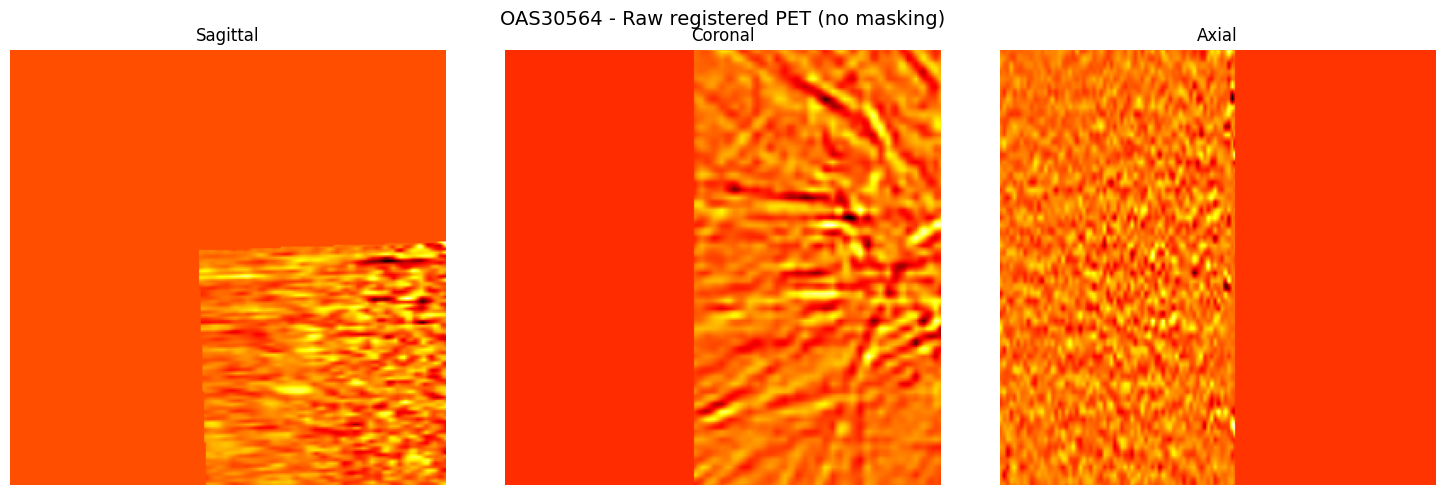

In [14]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

subj = df.iloc[0]
pet_raw = nib.load(f"E:/Oasis3/PET_registered/{subj['subject_id']}_PIB_in_MRI.nii.gz").get_fdata()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"{subj['subject_id']} - Raw registered PET (no masking)", fontsize=14)

mid_x = pet_raw.shape[0] // 2
mid_y = pet_raw.shape[1] // 2
mid_z = pet_raw.shape[2] // 2

axes[0].imshow(pet_raw[mid_x, :, :], cmap='hot', origin='lower')
axes[0].set_title('Sagittal')
axes[0].axis('off')

axes[1].imshow(pet_raw[:, mid_y, :], cmap='hot', origin='lower')
axes[1].set_title('Coronal')
axes[1].axis('off')

axes[2].imshow(pet_raw[:, :, mid_z], cmap='hot', origin='lower')
axes[2].set_title('Axial')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [15]:
import nibabel as nib
import matplotlib.pyplot as plt

subj = df.iloc[0]

# Check the ORIGINAL PET before registration
pet_orig_path = f"E:/pet scans/{subj['subject_id']}_PIB_d{int(df.iloc[0]['pet_day']):04d}/pet1/NIFTI/sub-{subj['subject_id']}_ses-d{int(df.iloc[0]['pet_day']):04d}_acq-PIB_pet.nii.gz"
print(f"Looking for: {pet_orig_path}")

import os
if os.path.exists(pet_orig_path):
    pet_orig = nib.load(pet_orig_path).get_fdata()
    print(f"Original PET shape: {pet_orig.shape}")
    print(f"Voxel size: {nib.load(pet_orig_path).header.get_zooms()}")
else:
    print("File not found - checking alternate path")
    pet_orig_path2 = f"E:/pet scans/{subj['subject_id']}_PIB_d{int(df.iloc[0]['pet_day']):04d}/pet1/sub-{subj['subject_id']}_ses-d{int(df.iloc[0]['pet_day']):04d}_acq-PIB_pet.nii.gz"
    print(f"Trying: {pet_orig_path2}")
    pet_orig = nib.load(pet_orig_path2).get_fdata()
    print(f"Original PET shape: {pet_orig.shape}")
    print(f"Voxel size: {nib.load(pet_orig_path2).header.get_zooms()}")

Looking for: E:/pet scans/OAS30564_PIB_d2808/pet1/NIFTI/sub-OAS30564_ses-d2808_acq-PIB_pet.nii.gz
Original PET shape: (128, 128, 109, 26)
Voxel size: (np.float32(2.32417), np.float32(2.32417), np.float32(2.0269928), np.float32(0.0))
